# Seaborn统计可视化

学习目标：用表格数据绘制 Seaborn 常用图表，调整分组、分布、统计区间和外观，理解图上的数值并保存成图。

前置知识：Python 模块导入、循环、列表与字典，NumPy 数组，pandas 表格与分组，Matplotlib Figure 和 Axes，均值、标准差与分位数。

运行环境：Python 3.12、Seaborn 0.13.2；其余依赖版本见环境说明。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

全部数据为本地教学模拟，不代表真实软件性能。图中使用英文标签：Payload 表示输入量，Latency 表示耗时，Group 表示组别，Load 表示负载。第 14 节导出 PNG 与 SVG 到临时目录，查看后可按该节说明清理。

阅读安排：第 1～4 节先掌握表格结构、字段映射和图形对象；第 5～7 节重点理解分布、聚合与误差区间；第 8～14 节比较多变量关系并完成导出。常用图表的用途、数据、核心绘制与参数调整都放在同一个代码单元，实际成图紧随其后；可以分段运行并改参数重画。

## 1 从一张散点图开始

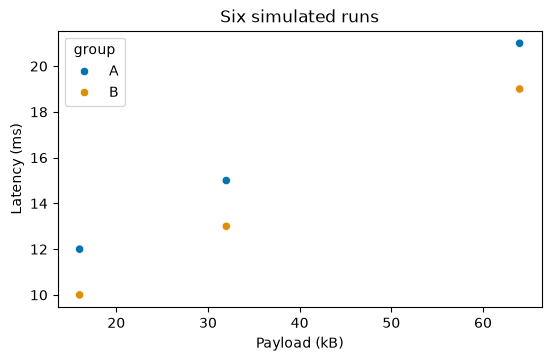

In [1]:
# 适用场景：散点图观察两个数值字段之间的关系，用颜色区分组别。
# 数据组织：每行是一次模拟运行；payload_kb 为输入量（kB），latency_ms 为耗时（ms）。
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

small = pd.DataFrame(
    {
        "payload_kb": [16, 32, 64, 16, 32, 64],
        "group": ["A", "A", "A", "B", "B", "B"],
        "latency_ms": [12, 15, 21, 10, 13, 19],
    }
)
# 最小绘制：scatterplot 的 data 取表格，x、y 指定横纵字段，ax 指向绘图区。
fig, ax = plt.subplots(figsize=(5.4, 3.5), layout="constrained")
# 常用参数调整：hue='group' 按组着色，palette='colorblind' 选择色盲友好配色。
# ax.set 补齐标签单位和标题，plt.show 显示图形。
sns.scatterplot(
    data=small, x="payload_kb", y="latency_ms", hue="group", palette="colorblind", ax=ax
)
ax.set(xlabel="Payload (kB)", ylabel="Latency (ms)", title="Six simulated runs")
# 实际成图：六个点对应六行；改变一个耗时值后重画，观察对应点的位置。
plt.show()
plt.close(fig)

## 2 长表与宽表

### 2.1 先辨认一次观测

长表（long-form）把变量放在列中、观测放在行中，small 就是长表。宽表（wide-form）可以把组别 A、B 展成两列：每个单元格的含义要结合行索引和列名判断。

pivot 只重排数据；同一输入量与组别必须只对应一个值。melt 把多列展开为“组别、耗时”两列。真实重复实验常有多行落在同一组合，不能为了 pivot 方便而随意丢掉重复观测。

In [2]:
wide = small.pivot(index="payload_kb", columns="group", values="latency_ms")
long_again = wide.reset_index().melt(
    id_vars="payload_kb", var_name="group", value_name="latency_ms"
)
print(wide)  # 预期：三行索引为 16/32/64，两列 A/B 分别为 12/15/21 与 10/13/19。
print(long_again)  # 预期：六行，先列 A 组三条再列 B 组三条，字段为 payload_kb、group、latency_ms。
keys = ["payload_kb", "group", "latency_ms"]
print(
    small.sort_values(keys)
    .reset_index(drop=True)
    .equals(long_again.sort_values(keys).reset_index(drop=True))
)  # 预期：True；转换前后仍是同样六次观测。

group        A   B
payload_kb        
16          12  10
32          15  13
64          21  19
   payload_kb group  latency_ms
0          16     A          12
1          32     A          15
2          64     A          21
3          16     B          10
4          32     B          13
5          64     B          19
True


### 2.2 宽表的映射由函数决定

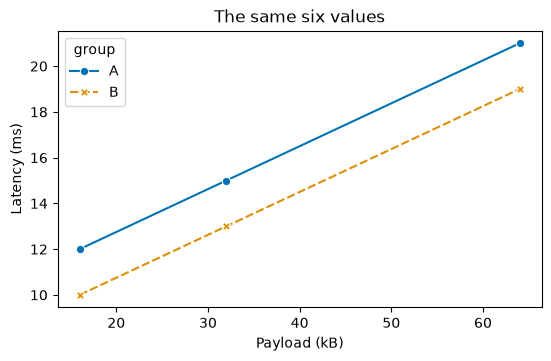

In [3]:
# 适用场景：用折线比较各组随有序输入量变化的数值。
# 数据组织：复用 wide；索引是输入量、列名是组别、单元格是耗时，仍是原来的六次观测。
# 许多 Seaborn 函数在省略 x、y 时按宽表解释数据，具体映射取决于函数。
# 最小绘制：lineplot(data=wide) 在这里将索引映射为横坐标，列映射为各条曲线。
fig, ax = plt.subplots(figsize=(5.4, 3.5), layout="constrained")
# 常用参数调整：estimator=None 关闭聚合，errorbar=None 关闭区间，markers=True 标出观测位置。
# 每个输入量和组别只有一个值；补齐单位，连线不代表中间也做过测量。
sns.lineplot(
    data=wide, estimator=None, errorbar=None, markers=True, palette="colorblind", ax=ax
)
ax.set(xlabel="Payload (kB)", ylabel="Latency (ms)", title="The same six values")
# 实际成图：两条线经过原来六个值；改 markers 或 palette 后核对数据位置不变。
plt.show()
plt.close(fig)

## 3 准备分组数据与视觉映射

### 3.1 构造一张有重复观测的小表

下面模拟四种“组别 × 负载”条件，每种 24 次独立运行，共 96 行。每次随机选择 16、32 或 64 kB 的输入，再加入均值为 0、标准差为 1.5 ms 的正态扰动。耗时基线、组别差与负载差都由代码人为设定。

run 是唯一行标识，不是配对对象。相同条件下的行来自相同生成规则；本章的重抽样把这些行视为独立观测。局部 Generator 固定种子，便于在当前环境复查。

In [4]:
rng = np.random.default_rng(2026)
rows = []
for group in ["A", "B"]:
    for load in ["Low", "High"]:
        for trial in range(24):
            payload = int(rng.choice([16, 32, 64]))
            latency = 8 + 0.16 * payload + 4 * (load == "High")
            latency -= 2 * (group == "B")
            latency += rng.normal(0, 1.5)
            rows.append((len(rows) + 1, group, load, payload, latency))
data = pd.DataFrame(rows, columns=["run", "group", "load", "payload_kb", "latency_ms"])
print(data.head().round(2))  # 预期：5 行、5 列；run 为 1～5、group=A、load=Low，输入量为 16/32/64 kB 之一。
print(data.groupby(["group", "load"]).size())  # 四个组合均为 24。
print(data.isna().sum().sum(), (data["latency_ms"] > 0).all())  # 0 True
# 固定种子下本次输入全部为正且没有缺失值；这不是正态扰动的取值保证。

   run group load  payload_kb  latency_ms
0    1     A  Low          64       18.60
1    2     A  Low          16        7.72
2    3     A  Low          16       11.52
3    4     A  Low          32       12.68
4    5     A  Low          64       18.70
group  load
A      High    24
       Low     24
B      High    24
       Low     24
dtype: int64
0 True


### 3.2 用颜色和点形表达字段

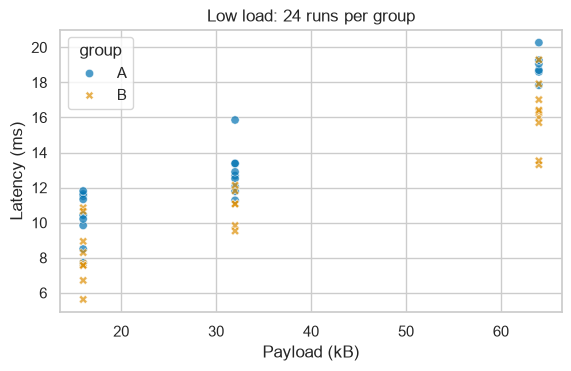

In [5]:
# 适用场景：在散点图上同时用颜色和点形区分组别，并减轻点重叠。
# 数据组织：从前面的 data 取 Low 负载的 48 行，避免把负载差混入组别比较。
# set_theme 设置白底网格和 notebook 显示尺度；固定组别颜色字典供后面的图复用。
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
group_order = ["A", "B"]
group_colors = dict(zip(group_order, sns.color_palette("colorblind", 2)))
low = data.loc[data["load"] == "Low"].copy()

# 最小绘制：scatterplot 接收 low 和两个坐标字段。
fig, ax = plt.subplots(figsize=(5.6, 3.6), layout="constrained")
# 常用参数调整：hue、style 都映射 group，hue_order 固定顺序，palette 固定跨图颜色。
# alpha=0.7 降低不透明度；完全重合时仍不能靠颜色精确计数。
sns.scatterplot(
    data=low,
    x="payload_kb",
    y="latency_ms",
    hue="group",
    style="group",
    hue_order=group_order,
    palette=group_colors,
    alpha=0.7,
    ax=ax,
)
ax.set(
    xlabel="Payload (kB)", ylabel="Latency (ms)", title="Low load: 24 runs per group"
)
# 实际成图：48 个点位于三种输入量，颜色和点形都区分 A、B；试改 alpha。
plt.show()
plt.close(fig)

## 4 单轴函数与整图函数

### 4.1 axes-level：放入指定子图

axes-level 函数画到一个 Axes，并返回该对象。用 plt.subplots 创建整个 Figure，再把各个 Axes 传给 ax，就能组合不同图形。figsize=(宽, 高) 的单位是英寸，控制整张图的尺寸。

| 函数 | 中文名称／含义 | 返回对象 |
| --- | --- | --- |
| scatterplot | 关系散点图 | Axes |
| histplot | 直方图 | Axes |
| relplot | 关系图与分面入口 | FacetGrid |
| displot | 分布图与分面入口 | FacetGrid |
| catplot | 分类图与分面入口 | FacetGrid |

下面先组合散点图和直方图；直方图把数值分组计数，第 5 节再比较分箱方法。

True


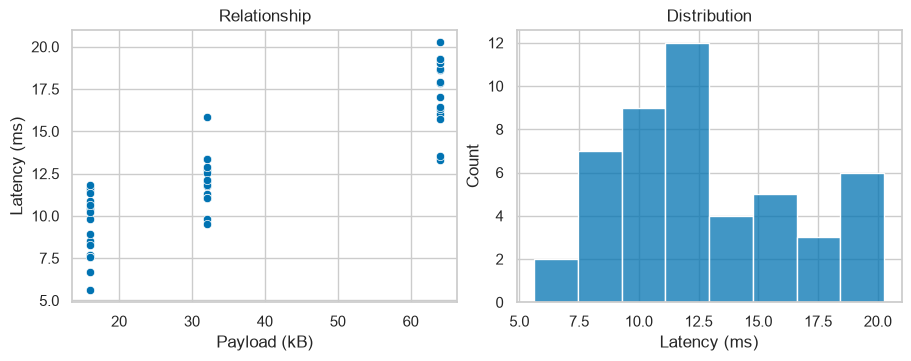

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")
returned_ax = sns.scatterplot(data=low, x="payload_kb", y="latency_ms", ax=axes[0])
sns.histplot(data=low, x="latency_ms", bins=8, ax=axes[1])
axes[0].set(xlabel="Payload (kB)", ylabel="Latency (ms)", title="Relationship")
axes[1].set(xlabel="Latency (ms)", ylabel="Count", title="Distribution")
print(returned_ax is axes[0])  # 预期：True；返回的就是传入的 Axes。
# 预期图形：左图 48 条输入的散点，右图同批耗时的 8 箱计数，总计 48。
plt.show()
plt.close(fig)

### 4.2 figure-level：按字段自动分面

FacetGrid (1, 2)


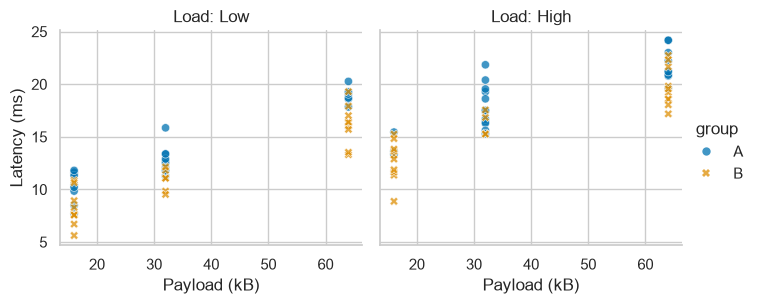

In [7]:
# 适用场景：分面散点图在不同条件下重复同一种图，便于比较。
# 数据组织：复用 data 的 96 行，col='load' 把 Low、High 分成两个面板。
# relplot 是 figure-level 函数，创建新整图并返回 FacetGrid，不能用 ax 放入任意已有子图。
# 最小绘制：relplot 接收坐标字段和 kind='scatter'，col 指定分面字段；row 可拆成行。
grid = sns.relplot(
    data=data,
    x="payload_kb",
    y="latency_ms",
    hue="group",
    style="group",
    col="load",
    col_order=["Low", "High"],
    kind="scatter",
    hue_order=group_order,
    palette=group_colors,
    height=3.2,
    aspect=1.1,
    facet_kws={"sharex": True, "sharey": True},
    alpha=0.75,
)
# 常用参数调整：height 是每个面板高度（英寸），aspect 为宽高比；面板增加时整图会变大。
# facet_kws 共享尺度，palette 固定组色；用返回对象的 set_axis_labels、set_titles 修改标签。
grid.set_axis_labels("Payload (kB)", "Latency (ms)")
grid.set_titles("Load: {col_name}")
print(type(grid).__name__, grid.axes.shape)  # 预期：FacetGrid (1, 2)
# 实际成图：每面板 48 行；试改 height 或 aspect，同时保持共享坐标。
plt.show()
plt.close(grid.figure)

## 5 比较分布的三种方式

### 5.1 直方图：分箱影响可见形状

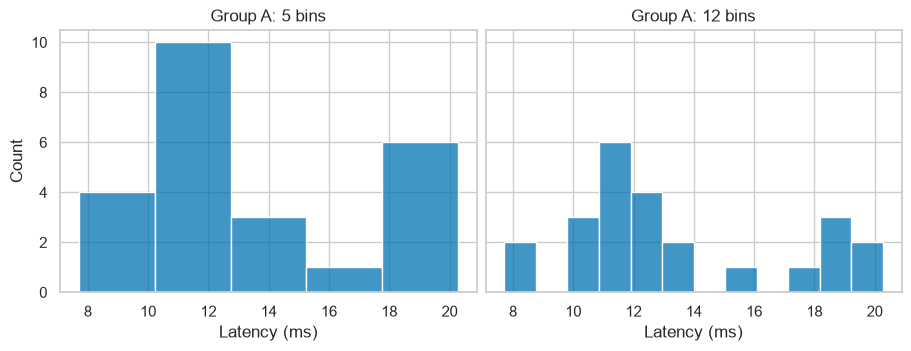

In [8]:
# 适用场景：直方图通过分箱计数观察数值分布。
# 数据组织：从 low 中取 A 组耗时，一维数据共 24 个值；两图输入完全相同。
one_group = low.loc[low["group"] == "A", "latency_ms"]
# 最小绘制：histplot(x=one_group) 统计各箱观测数；这里并列比较两种分箱。
fig, axes = plt.subplots(
    1, 2, figsize=(9, 3.4), sharex=True, sharey=True, layout="constrained"
)
# 常用参数调整：bins 可以是箱数或边界，binwidth 可以指定箱宽；两图仅将 bins 设为 5 和 12。
# 宽箱合并细节，窄箱突出零碎波动；柱峰变化不表示数据机制改变。
for ax, bins in zip(axes, [5, 12]):
    sns.histplot(x=one_group, bins=bins, color=group_colors["A"], ax=ax)
    ax.set(xlabel="Latency (ms)", ylabel="Count", title=f"Group A: {bins} bins")
# 实际成图：两图箱内计数各合计为 24；尝试第三种 bins，保留共享尺度再比较。
plt.show()
plt.close(fig)

### 5.2 比较组别时明确归一化口径

group
A    12
B    24
dtype: int64


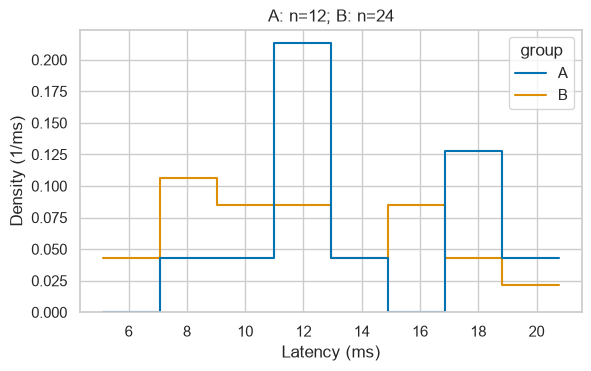

In [9]:
# 适用场景：分组密度直方图比较样本量不同的两组分布形状。
# 数据组织：复用 low，保留 A 前 12 行和 B 全部 24 行；两组共用 edges 箱边界。
unequal = pd.concat(
    [low.loc[low["group"] == "A"].head(12), low.loc[low["group"] == "B"]]
)
edges = np.linspace(low["latency_ms"].min() - 0.5, low["latency_ms"].max() + 0.5, 9)
print(unequal.groupby("group").size())  # 预期：A 为 12，B 为 24。
# 最小绘制：histplot 将 latency_ms 分箱，用 hue='group' 分组。
fig, ax = plt.subplots(figsize=(5.8, 3.6), layout="constrained")
# 常用参数调整：stat='density' 按柱面积表示比例，密度高度本身不是概率。
# common_norm=False 让每组面积各为 1；默认共同归一化则保留样本量对面积的影响。
# element='step'、fill=False 用轮廓减少遮挡；标题仍写样本数，归一化不会补回观测。
sns.histplot(
    data=unequal,
    x="latency_ms",
    hue="group",
    palette=group_colors,
    bins=edges,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=ax,
)
ax.set(xlabel="Latency (ms)", ylabel="Density (1/ms)", title="A: n=12; B: n=24")
# 实际成图：轮廓高低不能比较两组总人数；切换 common_norm 再观察面积含义。
plt.show()
plt.close(fig)

### 5.3 KDE：用带宽控制平滑程度

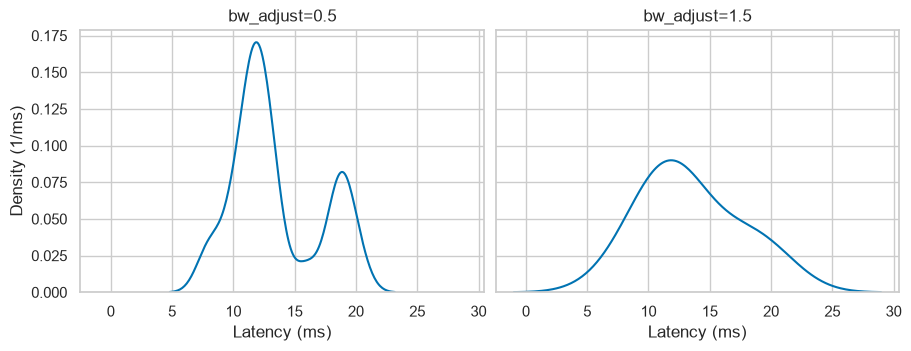

In [10]:
# 适用场景：核密度估计（KDE）用平滑曲线概括连续数据的密度。
# 数据组织：复用 one_group，即 A 组 Low 负载的 24 个耗时；曲线不是新增观测。
# 最小绘制：kdeplot(x=one_group) 估计密度。
fig, axes = plt.subplots(
    1, 2, figsize=(9, 3.4), sharex=True, sharey=True, layout="constrained"
)
# 常用参数调整：bw_adjust 缩放自动带宽；0.5 保留较多起伏，1.5 更平滑。
# 两图共享范围；过度平滑会抹掉结构，不能仅凭曲线好看选择带宽。
for ax, bandwidth in zip(axes, [0.5, 1.5]):
    sns.kdeplot(x=one_group, bw_adjust=bandwidth, color=group_colors["A"], ax=ax)
    ax.set(
        xlabel="Latency (ms)", ylabel="Density (1/ms)", title=f"bw_adjust={bandwidth}"
    )
# 实际成图：相同输入出现不同平滑程度；改变 bandwidth 的两项数值后再比较。
plt.show()
plt.close(fig)

### 5.4 有界数据：裁切曲线不等于修正估计

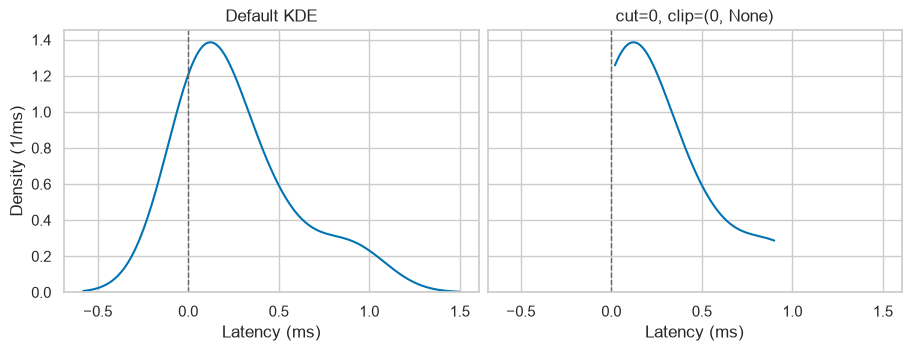

In [11]:
# 适用场景：观察 KDE 在有界数据附近的延伸，判断显示限制的作用。
# 数据组织：另造八个靠近 0 的正耗时（ms），与前面的分组数据无关。
# Seaborn 使用高斯核，曲线可能延伸到不可能的负耗时；此时也应看原始点、直方图或 ECDF。
bounded = [0.02, 0.04, 0.07, 0.10, 0.18, 0.30, 0.50, 0.90]
# 最小绘制：左图直接对 bounded 调用 kdeplot。
fig, axes = plt.subplots(
    1, 2, figsize=(9, 3.4), sharex=True, sharey=True, layout="constrained"
)
sns.kdeplot(x=bounded, ax=axes[0])
# 常用参数调整：右图 cut=0 限制到样本极值之间，clip 指定计算范围；二者不自动修正边界偏差。
sns.kdeplot(x=bounded, cut=0, clip=(0, None), ax=axes[1])
for ax, title in zip(axes, ["Default KDE", "cut=0, clip=(0, None)"]):
    ax.axvline(0, color="0.4", linestyle="--", linewidth=1)
    ax.set(xlabel="Latency (ms)", ylabel="Density (1/ms)", title=title)
# 实际成图：右图不画负值不等于边界估计正确；试改 cut，并观察 x=0 参考线。
plt.show()
plt.close(fig)

### 5.5 离散计数：保留实际取值

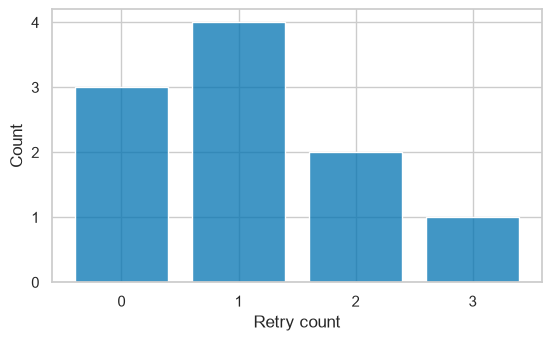

In [12]:
# 适用场景：离散直方图统计只能取整数的次数。
# 数据组织：retries 每个元素是一条记录的重试次数，0 表示没有重试。
# 平滑 KDE 会画出整数之间的密度，并可能制造没有依据的峰形，不适合作为本例主要展示。
retries = [0, 0, 0, 1, 1, 1, 1, 2, 2, 3]
# 最小绘制：histplot(x=retries, discrete=True) 让箱以整数为中心，宽度为 1。
fig, ax = plt.subplots(figsize=(5.4, 3.3), layout="constrained")
# 常用参数调整：shrink=0.8 缩窄显示的柱体以留间隔；xticks 只显示实际整数取值。
sns.histplot(x=retries, discrete=True, shrink=0.8, ax=ax)
ax.set(xlabel="Retry count", ylabel="Count", xticks=[0, 1, 2, 3])
# 实际成图：柱高为 3、4、2、1；增加一个整数记录再运行，核对对应柱变化。
plt.show()
plt.close(fig)

### 5.6 ECDF：直接读取阈值以下的比例

group
A    0.708
B    0.708
Name: within, dtype: float64


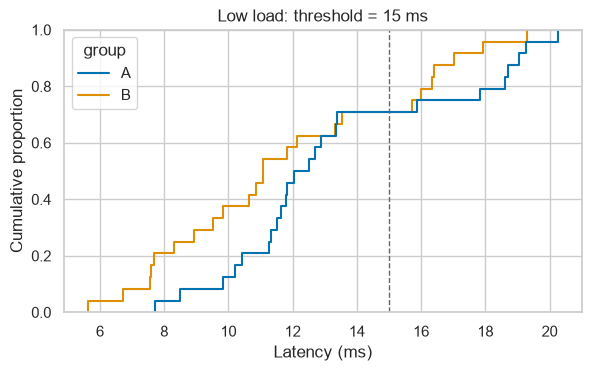

In [13]:
# 适用场景：经验累积分布函数（ECDF）读取不超过某阈值的样本比例，无须分箱或带宽。
# 数据组织：复用 low 的每组 24 个耗时；直接计数核对阈值 15 ms 对应比例。
# 重复值在同一位置一起增加；纵轴是累计比例而非密度，峰形通常不如直方图直观。
threshold = 15.0
fraction = (
    low.assign(within=low["latency_ms"] <= threshold).groupby("group")["within"].mean()
)
print(fraction.round(3))  # 预期：A、B 两行比例在 0～1 内、步长为 1/24；分别等于竖线处对应阶梯高度。
# 最小绘制：ecdfplot 按 x 字段绘制阶梯，hue 区分组别。
fig, ax = plt.subplots(figsize=(5.8, 3.6), layout="constrained")
sns.ecdfplot(data=low, x="latency_ms", hue="group", palette=group_colors, ax=ax)
# 常用参数调整：axvline 画阈值竖线，linestyle='--' 与曲线区分；palette 复用组别颜色。
ax.axvline(threshold, color="0.4", linestyle="--", linewidth=1)
ax.set(
    xlabel="Latency (ms)",
    ylabel="Cumulative proportion",
    title="Low load: threshold = 15 ms",
)
# 实际成图：两条曲线右端均为 1；改变 threshold，并把打印比例与竖线处高度比较。
plt.show()
plt.close(fig)

## 6 类别比较与原始观测

### 6.1 条带图与蜂群图

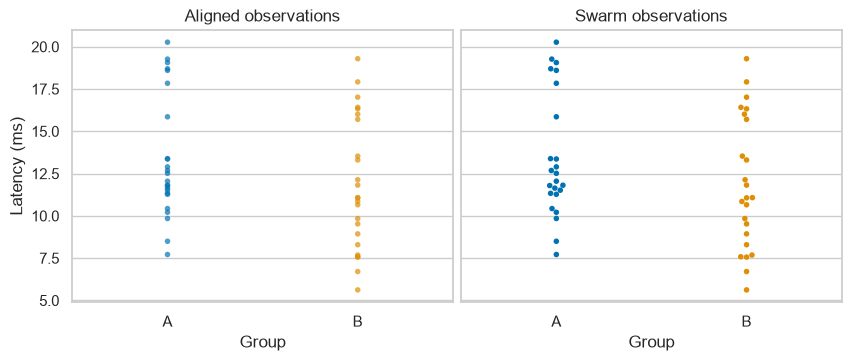

In [14]:
# 适用场景：条带图和蜂群图直接展示每组原始值；并列比较排列方式。
# 数据组织：复用 low，x 是类别 group，y 是耗时 latency_ms，每组 24 行。
# 最小绘制：stripplot、swarmplot 都接收数据表、类别字段与数值字段。
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.5), sharey=True, layout="constrained")
# 常用参数调整：stripplot 的 jitter 在类别方向随机偏移，不改变耗时；这里设 False 方便复查。
# swarmplot 在类别方向避让重叠，适合小数据；点太多或图太窄时可能无法全部排开。
# order 固定顺序，hue、palette 固定颜色；legend=False 避免重复列出横轴类别。
sns.stripplot(
    data=low,
    x="group",
    y="latency_ms",
    hue="group",
    order=group_order,
    palette=group_colors,
    jitter=False,
    legend=False,
    size=4,
    alpha=0.7,
    ax=axes[0],
)
sns.swarmplot(
    data=low,
    x="group",
    y="latency_ms",
    hue="group",
    order=group_order,
    palette=group_colors,
    legend=False,
    size=4,
    ax=axes[1],
)
for ax, title in zip(axes, ["Aligned observations", "Swarm observations"]):
    ax.set(xlabel="Group", ylabel="Latency (ms)", title=title)
# 实际成图：右图横向宽度只是排列结果，不能解释为新测量字段；试减小 size。
plt.show()
plt.close(fig)

### 6.2 重复值的重叠与避让

group  latency_ms
A      10            3
       11            2
       12            1
       13            1
       14            1
B      9             2
       10            3
       11            1
       12            1
       13            1
dtype: int64


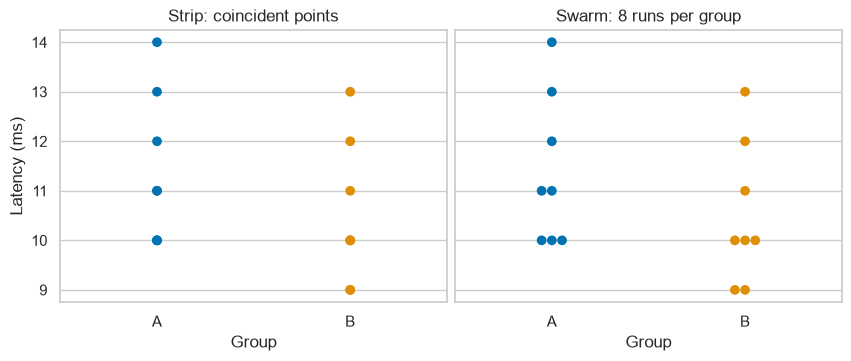

In [15]:
# 适用场景：比较完全重复的数值在条带图和蜂群图中如何显示。
# 数据组织：另造两组各 8 次模拟运行，刻意包含相同耗时；打印频数后再看点。
repeated = pd.DataFrame(
    {
        "group": ["A"] * 8 + ["B"] * 8,
        "latency_ms": [10, 10, 10, 11, 11, 12, 13, 14, 9, 9, 10, 10, 10, 11, 12, 13],
    }
)
print(repeated.groupby(["group", "latency_ms"]).size())  # 预期：A 的 10～14 ms 计数 3/2/1/1/1；B 的 9～13 ms 计数 2/3/1/1/1。
# 最小绘制：同一张 repeated 表分别传给 stripplot 和 swarmplot。
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.5), sharey=True, layout="constrained")
# 常用参数调整：jitter=False 使重复值完全重合；size=7 放大点，便于看蜂群避让。
# 若增加数据后出现排布警告，可减小点或扩大图幅，并重新观察；横向位置不表示额外变量。
sns.stripplot(
    data=repeated,
    x="group",
    y="latency_ms",
    hue="group",
    palette=group_colors,
    order=group_order,
    jitter=False,
    legend=False,
    size=7,
    ax=axes[0],
)
sns.swarmplot(
    data=repeated,
    x="group",
    y="latency_ms",
    hue="group",
    palette=group_colors,
    order=group_order,
    legend=False,
    size=7,
    ax=axes[1],
)
for ax, title in zip(axes, ["Strip: coincident points", "Swarm: 8 runs per group"]):
    ax.set(xlabel="Group", ylabel="Latency (ms)", title=title)
# 实际成图：左图每组只见五个位置，右图各见八个点；避让没有生成新观测。
plt.show()
plt.close(fig)

### 6.3 箱线图：分位数与须线

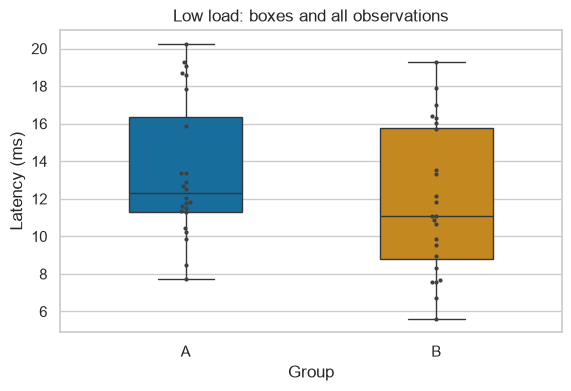

In [16]:
# 适用场景：箱线图概括每组的中位数、四分位范围与须线，叠加原始点补充局部信息。
# 数据组织：复用 low，类别为 group、数值为 latency_ms，每组仍是 24 行。
# 箱体从第 25 到 75 百分位，中线是中位数；两分位数之差为四分位距 IQR。
# 最小绘制：boxplot 指定 data、x、y，按类别绘制箱体。
fig, ax = plt.subplots(figsize=(5.6, 3.8), layout="constrained")
# 常用参数调整：width 控制箱宽；whis=1.5 将须线延至相邻箱边 1.5 IQR 范围内最远观测。
# 须线外的点不等于错误数据；另叠加小号 swarmplot，避免把箱体当成完整分布。
sns.boxplot(
    data=low,
    x="group",
    y="latency_ms",
    hue="group",
    order=group_order,
    palette=group_colors,
    legend=False,
    width=0.45,
    whis=1.5,
    ax=ax,
)
sns.swarmplot(
    data=low, x="group", y="latency_ms", order=group_order, color="0.25", size=3, ax=ax
)
ax.set(
    xlabel="Group", ylabel="Latency (ms)", title="Low load: boxes and all observations"
)
# 实际成图：中线不是均值，深色点保留各组 24 次观测；试调 width 或点大小。
plt.show()
plt.close(fig)

### 6.4 小提琴图：密度形状需要样本支持

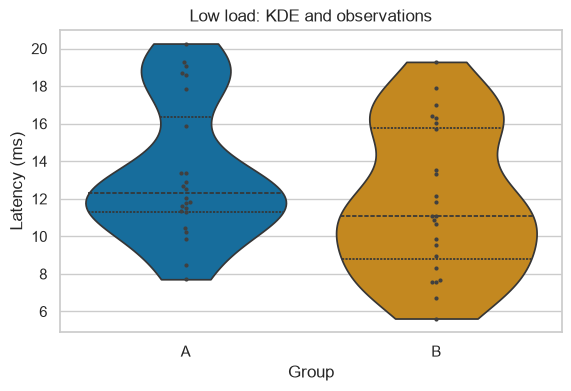

In [17]:
# 适用场景：小提琴图用 KDE 轮廓概括各组分布形状，并保留原始点作对照。
# 数据组织：复用 low 的组别和耗时，各组 24 个观测；小样本的光滑轮廓不等于确定的总体形状。
# 最小绘制：violinplot 根据 data、x、y 绘制各类别的密度轮廓。
fig, ax = plt.subplots(figsize=(5.6, 3.8), layout="constrained")
# 常用参数调整：inner='quart' 显示分位线；cut=0 不延伸到极端样本之外，bw_adjust 控制平滑。
# density_norm='area' 让各小提琴面积相同，不能按宽度读人数；'count' 可使宽度反映数量。
# 它仍受 KDE 的样本量和边界限制；叠加 swarmplot 查看真实观测。
sns.violinplot(
    data=low,
    x="group",
    y="latency_ms",
    hue="group",
    order=group_order,
    palette=group_colors,
    legend=False,
    inner="quart",
    cut=0,
    bw_adjust=0.8,
    density_norm="area",
    ax=ax,
)
sns.swarmplot(
    data=low, x="group", y="latency_ms", order=group_order, color="0.25", size=3, ax=ax
)
ax.set(xlabel="Group", ylabel="Latency (ms)", title="Low load: KDE and observations")
# 实际成图：轮廓是估计，深色点才对应记录；修改 bw_adjust，观察形状如何变化。
plt.show()
plt.close(fig)

## 7 聚合统计量与误差区间

### 7.1 先确认参与统计的观测

汇总前先明确分组字段、有效样本数和缺失值口径。下面显式排除绘图所需字段缺失的行，再计算每个“负载 × 组别”的均值、样本标准差与标准误；本次没有缺失，所以行数不变。

标准差（SD）描述观测的离散程度。对独立同分布样本的均值，估计标准误（SE）为 $s/\sqrt{n}$，其中 $s$ 是样本标准差，$n$ 是有效观测数。SE 关注均值估计的波动，不是单次观测的散布范围。

In [18]:
clean = data.dropna(subset=["group", "load", "payload_kb", "latency_ms"])
summary = clean.groupby(["load", "group"])["latency_ms"].agg(
    n="count", mean="mean", sd="std"
)
summary["se"] = summary["sd"] / np.sqrt(summary["n"])
print("原行数与有效行数：", len(data), len(clean))  # 96 96
print(summary.round(3))  # 预期：四行分组、n/mean/sd/se 四列，每行 n=24 且 se=sd/sqrt(24)。
# 每组 n=24；pandas 的 std 默认使用 n-1 分母。
# 这里的 SE 小于 SD；不能把 SE 当作单次运行的典型偏离幅度。

原行数与有效行数： 96 96
             n    mean     sd     se
load group                          
High A      24  18.943  3.163  0.646
     B      24  16.254  3.698  0.755
Low  A      24  13.439  3.649  0.745
     B      24  11.870  3.903  0.797


### 7.2 lineplot 会先聚合再连线

                  count   mean
group payload_kb              
A     16              9  10.33
      32              9  12.87
      64              6  18.96
B     16              9   8.21
      32              6  10.91
      64              9  16.17


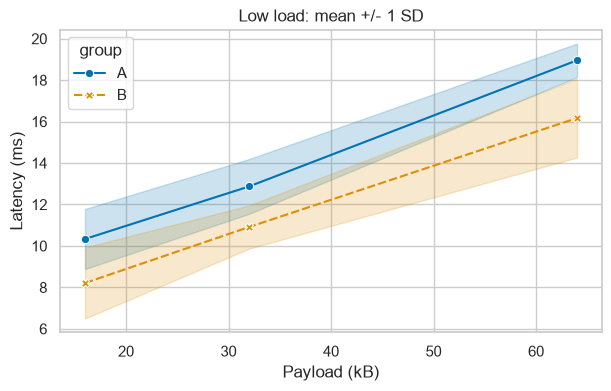

In [19]:
# 适用场景：聚合折线图比较每个有序输入量上的统计量。
# 数据组织：复用 low，按组别与输入量分组；先打印各组的有效观测数和均值。
# lineplot 默认对同组同一横坐标取均值并绘制置信区间，不是按表格行顺序连接原始点。
print(
    low.groupby(["group", "payload_kb"])["latency_ms"].agg(["count", "mean"]).round(2)
)
# 预期表格：A/B 各有 16/32/64 kB 三行，count 每组共 24，mean 与图中三点高度对应。
# 最小绘制：lineplot 指定 data、x、y 和 hue，得到各组的统计折线。
fig, ax = plt.subplots(figsize=(6, 3.8), layout="constrained")
# 常用参数调整：estimator='mean' 选择均值；errorbar='sd' 明确改为均值 ±1 SD。
# 色带描述该输入量下的数据散布，不是均值置信区间；markers、style 再用点形和线型区分组别。
sns.lineplot(
    data=low,
    x="payload_kb",
    y="latency_ms",
    hue="group",
    style="group",
    palette=group_colors,
    markers=True,
    estimator="mean",
    errorbar="sd",
    ax=ax,
)
ax.set(xlabel="Payload (kB)", ylabel="Latency (ms)", title="Low load: mean +/- 1 SD")
# 实际成图：每组只有三个均值点，原始观测更多；与打印的分组均值逐项对照。
plt.show()
plt.close(fig)

### 7.3 SD、SE 与 bootstrap CI 回答不同问题

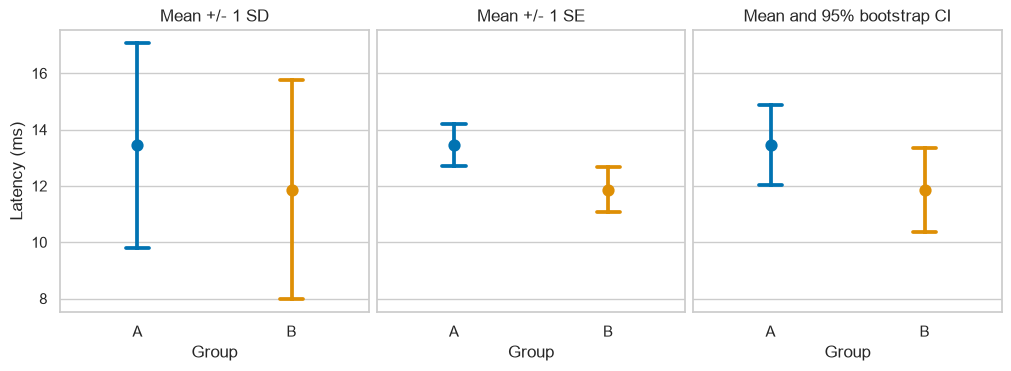

In [20]:
# 适用场景：点估计图用点表示类别汇总量，用误差条表达已选择的区间。
# 数据组织：复用 low，每组 24 行独立模拟；三个面板均使用相同均值。
# SD 描述样本散布，SE 与 CI 面向估计不确定性；±1 SE 不等于 95% CI。
# 最小绘制：pointplot 指定类别和数值字段，estimator='mean' 用点绘制均值。
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharey=True, layout="constrained")
# 常用参数调整：errorbar='sd'、'se'、('ci', 95) 分别给出 ±1 SD、±1 SE、95% bootstrap CI。
# bootstrap 在组内有放回重抽样，再取统计量的分位区间；n_boot=2000、seed=2026 固定本次演示。
# CI 不表示覆盖 95% 原始观测；重复测量同一对象时应按实际采样结构选择方法，不能直接视为独立行。
choices = [
    ("sd", "Mean +/- 1 SD"),
    ("se", "Mean +/- 1 SE"),
    (("ci", 95), "Mean and 95% bootstrap CI"),
]
for ax, (errorbar, title) in zip(axes, choices):
    sns.pointplot(
        data=low,
        x="group",
        y="latency_ms",
        hue="group",
        order=group_order,
        palette=group_colors,
        legend=False,
        estimator="mean",
        errorbar=errorbar,
        n_boot=2000,
        seed=2026,
        capsize=0.15,
        linestyles="none",
        ax=ax,
    )
    ax.set(xlabel="Group", ylabel="Latency (ms)", title=title)
# 实际成图：点相同而误差条不同；linestyles='none' 不连接类别，capsize 给误差条加端帽。
plt.show()
plt.close(fig)

## 8 回归关系图：在观测上叠加拟合线

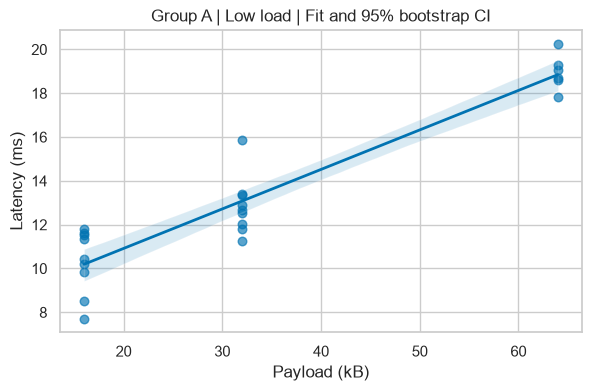

In [21]:
# 适用场景：回归图探索两个数值变量的近似线性趋势，查看散点与拟合线。
# 数据组织：从 low 取 A 组的 24 行，避免混入组别差和负载差。
# 这里拟合一条直线，与 lineplot 连接各输入量的均值不同；拟合或关联不能证明因果。
group_a = low.loc[low["group"] == "A"].copy()
# 最小绘制：regplot 的 data、x、y 指定原始散点与线性拟合的输入。
fig, ax = plt.subplots(figsize=(5.8, 3.8), layout="constrained")
# 常用参数调整：ci=95 画回归估计的 bootstrap 置信带；n_boot、seed 控制重抽样。
# 这不是覆盖 95% 单次观测的预测区间；scatter_kws 传散点参数，line_kws 传拟合线参数。
sns.regplot(
    data=group_a,
    x="payload_kb",
    y="latency_ms",
    color=group_colors["A"],
    ci=95,
    n_boot=2000,
    seed=2026,
    scatter_kws={"alpha": 0.65, "s": 38},
    line_kws={"linewidth": 2},
    ax=ax,
)
ax.set(
    xlabel="Payload (kB)",
    ylabel="Latency (ms)",
    title="Group A | Low load | Fit and 95% bootstrap CI",
)
# 实际成图：拟合线上升来自模拟规则；也要看原始点的弯曲或极端值，不能推断真实系统。
plt.show()
plt.close(fig)

## 9 联合分布图：关系与边缘分布一起看

JointGrid


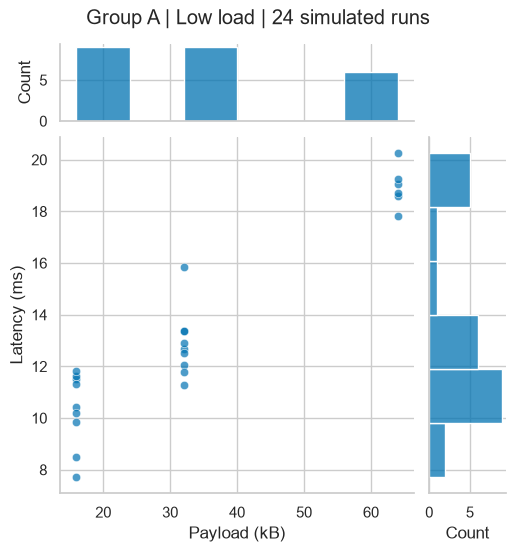

In [22]:
# 适用场景：联合分布图同时查看两变量的关系及各自分布。
# 数据组织：复用 group_a 同一批 24 行；边缘分布汇总单个变量，不保留两变量逐行配对。
# 最小绘制：jointplot 指定 data、x、y，kind='scatter' 在中央画散点、边缘画直方图。
joint = sns.jointplot(
    data=group_a,
    x="payload_kb",
    y="latency_ms",
    kind="scatter",
    height=5.4,
    ratio=4,
    color=group_colors["A"],
    marginal_ticks=True,
    joint_kws={"alpha": 0.7},
    marginal_kws={"bins": 6},
)
# 常用参数调整：height 设置方形图边长，ratio 设置中央与边缘的比例，marginal_kws 把 bins 传给直方图。
# 本例未设 hue；散点模式设置 hue 后默认边缘图改为 KDE，不能仍按直方图读取。
# 返回 JointGrid；set_axis_labels 设置中央标签，ax_marg_x、ax_marg_y 访问边缘轴并显示计数标签。
joint.set_axis_labels("Payload (kB)", "Latency (ms)")
joint.ax_marg_x.set_ylabel("Count")
joint.ax_marg_y.set_xlabel("Count")
joint.ax_marg_x.yaxis.label.set_visible(True)
joint.ax_marg_y.xaxis.label.set_visible(True)
joint.figure.suptitle("Group A | Low load | 24 simulated runs", y=1.02)
print(type(joint).__name__)  # 预期：JointGrid。
# 实际成图：两幅边缘图各计 24 行，中央仍保留配对；试改 marginal_kws 的 bins。
plt.show()
plt.close(joint.figure)

## 10 成对关系图：比较多个数值字段

  Group  Payload (kB)  Latency (ms)  Memory (MB)
0     A            64         18.60        58.83
1     A            16          7.72        41.43
2     A            16         11.52        46.08
3     A            32         12.68        54.24
4     A            64         18.70        59.23


PairGrid


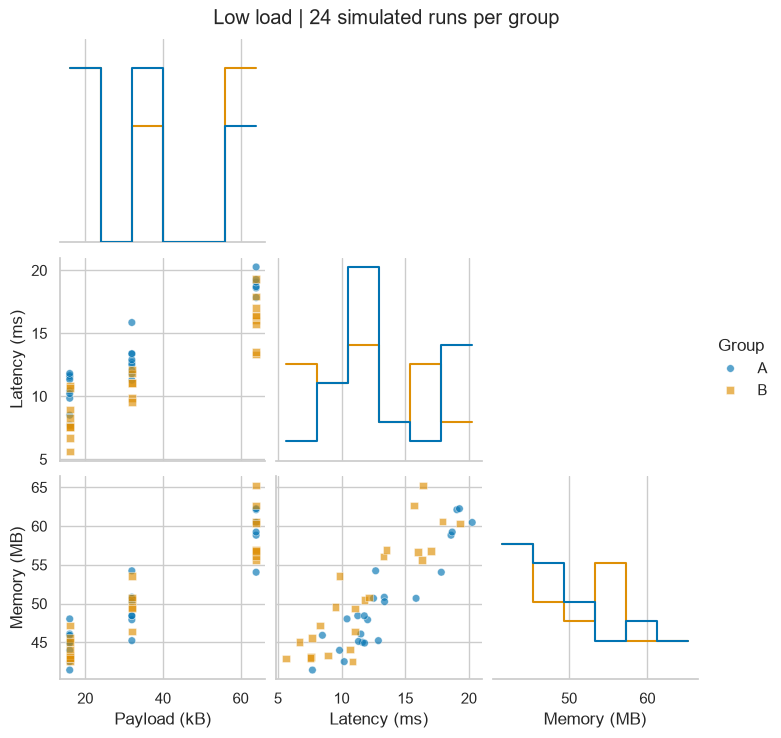

In [23]:
# 适用场景：成对关系图一次查看多个数值字段的两两关系与各自分布。
# 数据组织：复用 low 的 48 行，并模拟 Memory（MB）=40+0.3×Payload 加标准差为 2 MB 的扰动。
# rename 仅更改显示字段；内存和耗时都依赖输入量，关联不说明内存导致耗时增加。
relation_data = low.rename(
    columns={
        "group": "Group",
        "payload_kb": "Payload (kB)",
        "latency_ms": "Latency (ms)",
    }
).copy()
memory_rng = np.random.default_rng(2032)
relation_data["Memory (MB)"] = (
    40
    + 0.3 * relation_data["Payload (kB)"]
    + memory_rng.normal(0, 2, len(relation_data))
)
relation_vars = ["Payload (kB)", "Latency (ms)", "Memory (MB)"]
print(relation_data[["Group"] + relation_vars].head().round(2))  # 预期：5 行、4 列，Group=A；Memory 为约 40+0.3×Payload 加模拟扰动。
# 最小绘制：pairplot 接收表格，vars 明确选择三个测量字段，避免把 run 行标识误当变量。
pair = sns.pairplot(
    data=relation_data,
    vars=relation_vars,
    hue="Group",
    hue_order=group_order,
    palette=group_colors,
    markers=["o", "s"],
    kind="scatter",
    diag_kind="hist",
    corner=True,
    height=2.4,
    plot_kws={"alpha": 0.65, "s": 30},
    diag_kws={"bins": 6, "element": "step", "fill": False},
)
# 常用参数调整：kind='scatter' 画关系，diag_kind='hist' 画自身分布；corner=True 省略重复的上三角。
# height 设置每面板高度，plot_kws 和 diag_kws 分别调整散点与对角线；返回对象为 PairGrid。
# 变量多时先用 vars 缩小范围；同一批观测重复出现在面板中不会增加样本量。
pair.figure.suptitle("Low load | 24 simulated runs per group", y=1.02)
print(type(pair).__name__)  # 预期：PairGrid。
# 实际成图：三个分布图和三个不重复的关系图；试减少 vars，观察布局如何变化。
plt.show()
plt.close(pair.figure)

## 11 相关性矩阵热力图：先计算，再用颜色表达

共同有效观测数： 24
              Payload (kB)  Latency (ms)  Memory (MB)
Payload (kB)          1.00          0.94         0.93
Latency (ms)          0.94          1.00         0.92
Memory (MB)           0.93          0.92         1.00


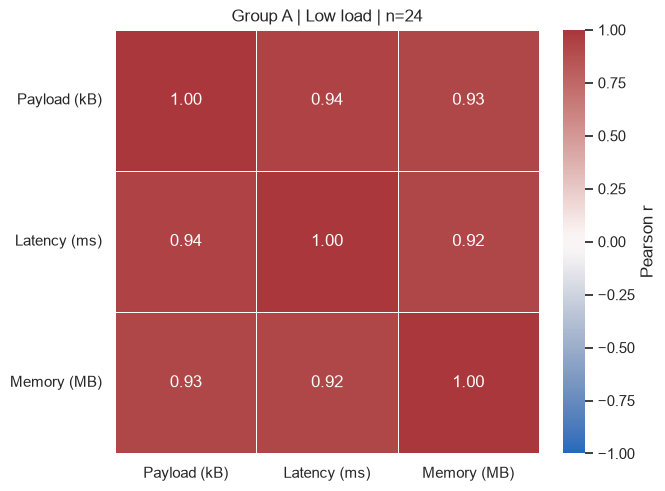

In [24]:
# 适用场景：相关矩阵热力图用颜色概括字段间的线性相关。
# 数据组织：从 relation_data 取 A 组，先排除任一所选字段缺失的行，保证各格使用同一批 24 行。
# corr 原本按字段对排除缺失，未统一有效行时不同格的样本数可能不同；heatmap 不自动计算相关性。
# Pearson 系数在 −1～1，接近 0 不能排除非线性关系，常量字段的系数没有定义。
# 矩阵隐藏分布形状与离群点，也不能作为因果证据，应与原始散点对照。
corr_data = relation_data.loc[relation_data["Group"] == "A", relation_vars].dropna()
correlation = corr_data.corr(method="pearson")
print("共同有效观测数：", len(corr_data))  # 预期：24。
print(correlation.round(2))  # 预期：3×3 对称矩阵、对角线为 1、非对角值与图中标注一致。
# 最小绘制：先 corr(method='pearson') 得到数值矩阵，再交给 heatmap。
fig, ax = plt.subplots(figsize=(6.4, 4.8), layout="constrained")
# 常用参数调整：vmin=-1、vmax=1 固定范围，center=0、cmap='vlag' 区分正负。
# annot=True 显示数值，fmt='.2f' 保留两位小数，cbar_kws 写明 Pearson r；系数本身没有物理单位。
sns.heatmap(
    correlation,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title("Group A | Low load | n=24")
ax.tick_params(axis="x", labelrotation=0)
ax.tick_params(axis="y", labelrotation=0)
# 实际成图：矩阵对称、对角线为 1；对照打印值与颜色，再回看散点中的形状和离群点。
plt.show()
plt.close(fig)

## 12 局部样式与显示上下文

axes_style 主要控制背景、网格等外观，plotting_context 控制文字与线条等元素的相对大小；两者可放在 with 中局部使用。paper、notebook、talk、poster 对应不同的显示尺度，选择 paper 不代表已经符合投稿要求。

下面固定图幅，只比较 notebook 与 paper 上下文。使用 ticks 白底样式，并用 despine 去掉上、右边框。离开 with 后恢复外部配置；最终字号仍要在实际阅读尺寸检查。

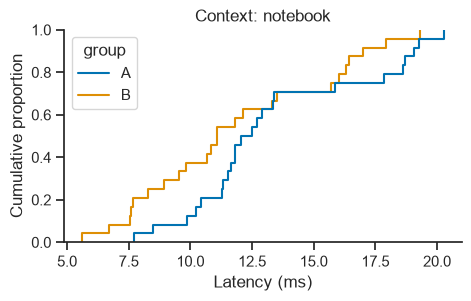

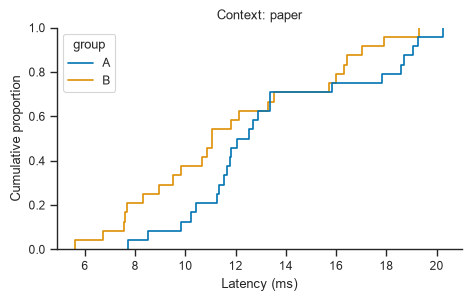

In [25]:
for context in ["notebook", "paper"]:
    with sns.axes_style("ticks"), sns.plotting_context(context):
        fig, ax = plt.subplots(figsize=(4.6, 2.9), layout="constrained")
        sns.ecdfplot(data=low, x="latency_ms", hue="group", palette=group_colors, ax=ax)
        ax.set(
            xlabel="Latency (ms)",
            ylabel="Cumulative proportion",
            title=f"Context: {context}",
        )
        sns.despine(ax=ax)
        plt.show()
        plt.close(fig)
# 图幅与数据不变，文字和线条比例不同；比较小尺寸下的可读性。

## 13 组合练习：ECDF 与均值点估计图

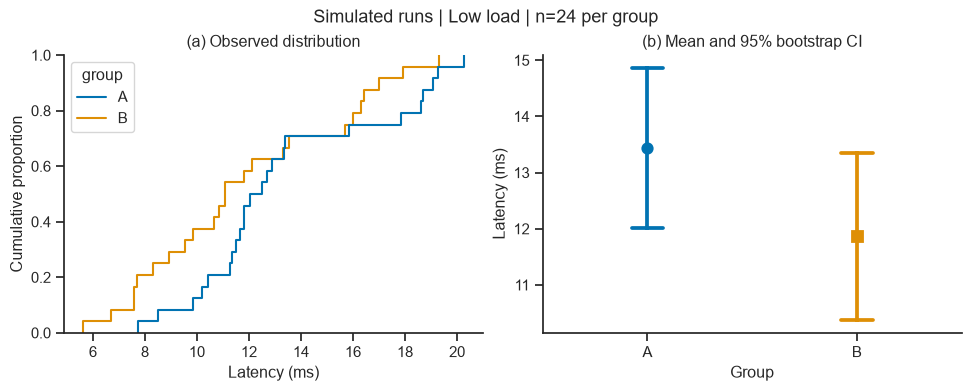

In [26]:
# 组合练习：将 ECDF 与均值点估计图并列，观察两种图保留的信息。
# 数据组织：复用 low，每组 24 行，混合了随机抽到的三种输入量；两图是同一批数据。
# 若要比较相同输入量下的组别差，应先按输入量筛选或分层；模拟图不能解释为真实性能结论。
# 最小绘制：创建两个 Axes，分别调用已学的 ecdfplot、pointplot。
# 常用参数调整：复用组别颜色和点形；右图明确用均值与 95% bootstrap CI，标题写清口径。
with sns.axes_style("ticks"), sns.plotting_context("notebook", font_scale=0.95):
    report_fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.8), layout="constrained")
    sns.ecdfplot(
        data=low, x="latency_ms", hue="group", palette=group_colors, ax=axes[0]
    )
    sns.pointplot(
        data=low,
        x="group",
        y="latency_ms",
        hue="group",
        order=group_order,
        palette=group_colors,
        markers=["o", "s"],
        legend=False,
        linestyles="none",
        estimator="mean",
        errorbar=("ci", 95),
        n_boot=2000,
        seed=2026,
        capsize=0.15,
        ax=axes[1],
    )
    axes[0].set(
        xlabel="Latency (ms)",
        ylabel="Cumulative proportion",
        title="(a) Observed distribution",
    )
    axes[1].set(
        xlabel="Group", ylabel="Latency (ms)", title="(b) Mean and 95% bootstrap CI"
    )
    report_fig.suptitle("Simulated runs | Low load | n=24 per group", fontsize=13)
    sns.despine(fig=report_fig)
    # 实际成图：左图保留累计比例，右图浓缩成均值和区间；先解释差别，再尝试筛选输入量重画。
    plt.show()
    plt.close(report_fig)

## 14 导出与清理

Figure.savefig 按扩展名选择格式。PNG 是位图，当前 9.6 × 3.8 英寸的图按 200 dpi 输出为 1920 × 760 像素；SVG 保留本例线条与文字等图元的矢量表示。导出时的尺寸仍需与最终用途匹配。

tempfile.mkdtemp 创建临时目录并保留文件。打开输出目录查看两种格式：检查轴单位、图例、CI 口径、文字裁切和实际显示尺寸。plt.close 只关闭图形的显示管理，不删除文件，也不妨碍通过保留的 Figure 引用保存。

In [27]:
import tempfile
from pathlib import Path

output_dir = Path(tempfile.mkdtemp(prefix="seaborn-ch02-"))
png_path = output_dir / "latency-report.png"
svg_path = output_dir / "latency-report.svg"
report_fig.savefig(png_path, dpi=200, facecolor="white")
report_fig.savefig(svg_path, facecolor="white")
print("输出目录：", output_dir)  # 预期：seaborn-ch02- 开头的本次临时目录；随机后缀会变化。
print(png_path.name, png_path.stat().st_size > 0)
print(svg_path.name, svg_path.stat().st_size > 0)
# 两个文件均应非空；文件存在只是保存检查，还需实际查看图形。

输出目录： C:\Users\ZHUANG\AppData\Local\Temp\seaborn-ch02-gw8tybrs
latency-report.png True
latency-report.svg True


完成查看后，把下面的 cleanup 改为 True，再运行此单元。只删除本章创建的两个文件和它们所在的空目录；再次导出时重新运行上一个单元。

In [28]:
cleanup = False
if cleanup:
    png_path.unlink()
    svg_path.unlink()
    output_dir.rmdir()
    print("已清理本次导出文件")  # 预期：仅在 cleanup=True 且删除完成后显示。
else:
    print("保留导出文件，供查看")  # 预期：默认 cleanup=False，显示此提示并保留文件。

保留导出文件，供查看


## 本章小结

（1）先明确一次观测及字段含义；长宽表转换改变组织方式，不能无意改变观测数或聚合口径。

（2）axes-level 接收 Axes，figure-level 创建整图；FacetGrid、JointGrid 和 PairGrid 各自组织不同的多图布局。

（3）直方图依赖分箱，KDE 依赖带宽与连续性条件，ECDF 不需要平滑参数；条带图与蜂群图保留原始值，箱线图与小提琴图提供分布概括。

（4）回归图叠加拟合线，联合分布图补充边缘分布，成对关系图比较多个字段；相关热力图先计算再绘制，不能替代原始点或证明因果。

（5）区分 SD、SE 与 CI，注明分组、样本量及缺失值口径；跨图保持颜色语义，实际查看 PNG 与 SVG 导出效果。

自查：同一批数据换成 KDE、ECDF 和均值区间图，分别隐藏了什么？为什么 95% CI 不能解释为 95% 的单次观测落入其中？

## 练习

（1）把下面宽表转换为长表并绘制分组散点图。每个数值单元格代表一次模拟观测，trial 只是行标识。核对转换后有 8 行、每组 4 行，单位为 ms；说明为什么转成长表不会增加独立实验的数量。

In [29]:
exercise_wide = pd.DataFrame(
    {
        "trial": [1, 2, 3, 4],
        "A": [9.0, 10.0, 11.0, 12.0],
        "B": [8.5, 9.5, 10.5, 11.5],
    }
)
# 在此转换并绘图；横轴为 trial，纵轴为 latency_ms，颜色为 group。
# 检查：两个组各 4 个点；第一行的值仍是 A=9.0、B=8.5。

（2）对以下只能取整数的数据，分别画 discrete=True 的直方图与 ECDF。说明各图突出或隐藏的信息，并解释为什么不把平滑 KDE 作为主要展示。用直接计数核对“不超过 1 次重试”的比例。

In [30]:
exercise_retries = [0, 0, 1, 1, 1, 2, 3, 4]
# 在此创建两个子图并补齐标签。
# 检查：总数为 8，不超过 1 次的比例为 5/8；ECDF 右端为 1。

（3）给综合应用增加约束：只比较 High 负载且输入量为 32 kB 的观测。先打印每组样本数，再用原始点与均值 ±1 SD 并列展示，另存 PNG。解释相较于原综合图，比较对象、样本量和误差条含义分别发生了什么变化。

In [31]:
exercise_data = data.loc[(data["load"] == "High") & (data["payload_kb"] == 32)].copy()
# 在此核对每组样本数，并选择两个 axes-level 函数组合图形。
# 检查：每个均值等于对应子表的平均数；标题写明 Mean +/- 1 SD。
# 沿用临时目录导出方式；记录文件位置并在查看后显式清理。

（4）以下是刻意构造的五行曲线数据，x、y 均无单位。先画 jointplot，再计算 Pearson 相关矩阵并画热力图，固定色条范围为 −1 到 1。比较两种图各自突出或隐藏的信息，并说明能否根据接近 0 的系数断言“两个变量没有关系”。

In [32]:
exercise_curve = pd.DataFrame({"x": [-2, -1, 0, 1, 2], "y": [4, 1, 0, 1, 4]})
# 在此完成联合分布图和相关热力图；每幅图均使用这 5 行。
# 检查：热力图与打印矩阵一致；比较线性关联摘要与原始点形状。
# 写出各图隐藏的信息，并说明相关或拟合结果为何不足以支持因果判断。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：先统计每个整数的频数，再累计到阈值 1。

提示 2：ECDF 的纵坐标是累计比例；KDE 的平滑会掩盖本题只能取整数的条件。

### 练习（2）参考解析

0、1、2、3、4 次的频数分别为 2、3、1、1、1，总数为 8。ECDF 在这些位置依次达到 $2/8,5/8,6/8,7/8,1$，因此“不超过 1 次”的比例为 $5/8=62.5\%$。

离散直方图突出各整数的频数；ECDF 便于读取阈值以下的比例，频数需从跳跃大小反推。平滑 KDE 会给非整数之间画出密度曲线，不宜作为这类离散计数的主要展示。两种图都汇总了记录，没有保留每次重试属于哪个对象或发生在何时。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Seaborn 0.13.2 官方文档 | [Data structures](https://seaborn.pydata.org/tutorial/data_structure.html) 的 Long-form vs. wide-form data；[Function overview](https://seaborn.pydata.org/tutorial/function_overview.html) 的 Figure-level vs. axes-level functions、Specifying figure sizes；[scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)、[relplot](https://seaborn.pydata.org/generated/seaborn.relplot.html)：字段映射、分面与返回对象；[lineplot](https://seaborn.pydata.org/generated/seaborn.lineplot.html)：estimator、errorbar 与排序；[Distributions](https://seaborn.pydata.org/tutorial/distributions.html) 的分箱、带宽、KDE pitfalls 与 ECDF；[histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html)：stat、common_norm、bins、discrete、shrink；[kdeplot](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)：bw_adjust、cut、clip 与 Notes；[ecdfplot](https://seaborn.pydata.org/generated/seaborn.ecdfplot.html)：累计比例；[Categorical tutorial](https://seaborn.pydata.org/tutorial/categorical.html)、[stripplot](https://seaborn.pydata.org/generated/seaborn.stripplot.html)、[swarmplot](https://seaborn.pydata.org/generated/seaborn.swarmplot.html)：观测点、抖动与避让；[boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)：whis；[violinplot](https://seaborn.pydata.org/generated/seaborn.violinplot.html)：inner、cut、density_norm；[Error bars](https://seaborn.pydata.org/tutorial/error_bars.html) 的 Measures of data spread、Measures of estimate uncertainty；[pointplot](https://seaborn.pydata.org/generated/seaborn.pointplot.html)：estimator、errorbar、n_boot、seed、units；[Aesthetics](https://seaborn.pydata.org/tutorial/aesthetics.html)：局部样式、despine 与 Scaling plot elements；[Color palettes](https://seaborn.pydata.org/tutorial/color_palettes.html)：分类颜色、辅助形状与 colorblind。[regplot](https://seaborn.pydata.org/generated/seaborn.regplot.html)：ci、n_boot、seed、scatter_kws 与 line_kws；[Regression tutorial](https://seaborn.pydata.org/tutorial/regression.html) 的 Functions for drawing linear regression models、Fitting different kinds of models：探索性拟合与原始点；[jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html)：kind、height、ratio、marginal_kws、hue 对边缘图的影响；[JointGrid](https://seaborn.pydata.org/generated/seaborn.JointGrid.html) 的访问 ax_joint、ax_marg_x、ax_marg_y 示例；[pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)：vars、diag_kind、corner、markers 与 PairGrid；[heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)：矩阵输入、annot、fmt、vmin、vmax、center 与色条；上述 Color palettes 的 Diverging color palettes：vlag 与零中心配色。读者选图入口：[官方示例图库](https://seaborn.pydata.org/examples/index.html)。 |
| pandas 3.0.6 官方文档 | [DataFrame.pivot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot.html)：重排与重复组合限制；[DataFrame.melt](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.melt.html)：标识列与值列；[DataFrame.dropna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)：subset；[Series.std](https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html)：样本标准差与默认 ddof=1；[Group by: Named aggregation](https://pandas.pydata.org/docs/user_guide/groupby.html#named-aggregation)：分组汇总和命名统计量；[DataFrame.rename](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html)：显示字段重命名；[DataFrame.corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) 的 method、Notes：Pearson 相关矩阵与逐对完整观测。 |
| NumPy 官方文档 | [Random Generator](https://numpy.org/doc/stable/reference/random/generator.html)：default_rng、局部生成器和种子；[Generator.normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html)、[Generator.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html)：扰动与输入抽取；模拟生成规则为本章自定。 |
| SciPy 官方文档 | [stats.ecdf](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ecdf.html) 的 Notes 与 Examples：经验累计分布及阶梯取值；本章绘图使用 Seaborn；[bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html)：有放回重抽样、统计量分布与 percentile 区间；[sem](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sem.html)：均值标准误与自由度；[pearsonr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) 的定义、ConstantInputWarning 与 Examples：线性相关范围、常量边界与非线性关系；本章用 pandas 计算矩阵。 |
| Matplotlib 3.11.2 官方文档 | [subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)：整图尺寸、共享坐标轴与子图返回；[Figure.savefig](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html)：格式、dpi 与导出；[close](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.close.html)：关闭及取消图形注册；[Text.set_visible](https://matplotlib.org/stable/api/text_api.html#matplotlib.text.Text.set_visible)：边缘轴标签的可见性。 |
| Python 3.12 官方文档 | [tempfile.mkdtemp](https://docs.python.org/3.12/library/tempfile.html#tempfile.mkdtemp)、[Path.unlink](https://docs.python.org/3.12/library/pathlib.html#pathlib.Path.unlink)、[Path.rmdir](https://docs.python.org/3.12/library/pathlib.html#pathlib.Path.rmdir)：临时目录和显式清理。 |
| Python Graph Gallery | [Seaborn 专题入口](https://python-graph-gallery.com/seaborn/)：供读者按图形类型寻找配色与布局思路；接口行为以对应版本的官方文档为准。本章数据与代码独立编写，未复制站内示例。 |
| NIST/SEMATECH e-Handbook | [§1.3.3.26 Scatter Plot](https://www.itl.nist.gov/div898/handbook/eda/section3/scatterp.htm) 的 Questions、Combining Scatter Plots 与 Causality Is Not Proved By Association：关系形状、多变量比较及关联不能证明因果。 |